In [ ]:
# Cell 1: Setup and Imports
%matplotlib inline
import sys
import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path
CURRENT_SCRIPT_DIR = os.getcwd()
PARENT_PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_SCRIPT_DIR, ".."))
sys.path.append(os.path.join(PARENT_PROJECT_ROOT, "src"))  
sys.path.insert(0, PARENT_PROJECT_ROOT) 

from shap_rtl.plots import (
    waterfall, bar, beeswarm, summary_plot,
    heatmap, scatter, decision_plot, dependence_plot
)
from shap_rtl import RTLSHAPExplainer

# Output directory
OUTPUT_DIR = os.path.join(os.getcwd(), "Arabic_language_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"✅ Imports loaded successfully!")

✅ Imports loaded successfully!
📁 Output directory: c:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\tests\Arabic_language_plots


In [20]:
# Cell 2: Load Data and Train Model
DATA_FILE = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\rtl_multilingual_dataset.xlsx'

# Load dataset
df = pd.read_excel(DATA_FILE)
texts = df['cleaned_text'].astype(str).fillna('')

# Find label column
label_col = None
for col in ['multi_class', 'label', 'class', 'category', 'type', 'labels']:
    if col in df.columns:
        label_col = col
        break

if label_col is None:
    for col in df.columns:
        if df[col].dtype == 'object' and df[col].nunique() < 20:
            label_col = col
            break

if label_col is None:
    raise ValueError("No label column found in dataset.")

labels_text = df[label_col]
print(f"📊 Using label column: {label_col}")
print(f"📊 Unique classes: {labels_text.unique()}")

# Encode labels
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(labels_text)
class_names = label_encoder.classes_
print(f"📊 Class mapping: {dict(zip(class_names, range(len(class_names))))}")
print(f"📊 Samples: {len(texts)}")
print(f"📊 Class distribution: {np.bincount(labels)}")

# Train model
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=300)
X = vectorizer.fit_transform(texts).toarray()

model = LogisticRegression(
    max_iter=1000, 
    class_weight='balanced',
    solver='lbfgs'
).fit(X, labels)

print(f"✅ Model trained with {X.shape[1]} features")
print(f"✅ Model classes: {model.classes_}")

📊 Using label column: multi_class
📊 Unique classes: <StringArray>
['Neutral', 'General Violence']
Length: 2, dtype: str
📊 Class mapping: {'General Violence': 0, 'Neutral': 1}
📊 Samples: 72
📊 Class distribution: [12 60]
✅ Model trained with 300 features
✅ Model classes: [0 1]


In [17]:
# Cell 3: FIND ARABIC SAMPLE WITH FEATURES
# The Arabic sample you want to use
target_arabic = "رياح خفيفة تحمل نسمات منعشة، يا لها من أجواء رائعة."

print(f"🔍 Searching for: {target_arabic}")

# Find a sample with features
sample_idx = None
sample_text = None
sample_label = None

# First, try to find the exact tweet
for idx, text in enumerate(texts):
    if text.strip() == target_arabic.strip():
        # Check if it has features
        instance = vectorizer.transform([text]).toarray()[0]
        if np.sum(instance) > 0:
            sample_idx = idx
            sample_text = text
            sample_label = labels[idx]
            print(f"\n✅ Found the exact tweet with features!")
            break

# If not found or no features, find any Arabic sample with features
if sample_idx is None:
    print("\n⚠️ Exact tweet has no features or not found. Finding any Arabic sample with features...")
    for idx, text in enumerate(texts):
        # Check if it's Arabic
        if any('\u0600' <= char <= '\u06FF' for char in text):
            instance = vectorizer.transform([text]).toarray()[0]
            if np.sum(instance) > 0:
                sample_idx = idx
                sample_text = text
                sample_label = labels[idx]
                print(f"\n✅ Found Arabic sample with features at index {idx}")
                break

# If still no Arabic sample, find any sample with features
if sample_idx is None:
    print("\n⚠️ No Arabic sample with features found. Using any sample with features...")
    for idx, text in enumerate(texts):
        instance = vectorizer.transform([text]).toarray()[0]
        if np.sum(instance) > 0:
            sample_idx = idx
            sample_text = text
            sample_label = labels[idx]
            print(f"\n✅ Found sample with features at index {idx}")
            break

# If still nothing, use first sample
if sample_idx is None:
    sample_idx = 0
    sample_text = texts.iloc[0]
    sample_label = labels[0]
    print(f"\n⚠️ Using first sample: {sample_text[:100]}...")

print(f"\n📝 Selected sample:")
print(f"   {sample_text}")
print(f"   Label: {class_names[sample_label]}")

# Vectorize and predict
user_instance = vectorizer.transform([sample_text]).toarray()[0]
present_idx = np.where(user_instance > 0)[0]
user_pred = model.predict(user_instance.reshape(1, -1))[0]
user_prob = model.predict_proba(user_instance.reshape(1, -1))[0]

print(f"\n📊 Features present: {len(present_idx)}")
print(f"🔮 Model Prediction: {class_names[user_pred]}")
print(f"📊 Prediction Probability: {user_prob[user_pred]:.3f}")

🔍 Searching for: رياح خفيفة تحمل نسمات منعشة، يا لها من أجواء رائعة.

⚠️ Exact tweet has no features or not found. Finding any Arabic sample with features...

✅ Found Arabic sample with features at index 0

📝 Selected sample:
   یے وقت ہے بلوچستان کو ٹھیک کرنے کا ۔ جو جو سردار وہاں کا ملوٽ ہے ان کو الٹا لٹکا دو ۔ کافی خون بہہ چکا ہے ۔ ۔ ۔ سڑکوں پر لٹکاؤ سارے حرامزادوں کو ۔
   Label: 1

📊 Features present: 13
🔮 Model Prediction: 1
📊 Prediction Probability: 0.918


In [21]:
# Cell 4: Compute SHAP Values for Arabic Tweet (Multi-Class)
# For LogisticRegression, we need to handle multi-class SHAP values
masker = shap.maskers.Independent(data=X, max_samples=100)

# If using OneVsRestClassifier, get the base estimator
if hasattr(model, 'estimator'):
    base_model = model.estimator
else:
    base_model = model

explainer_shap = shap.LinearExplainer(base_model, masker=masker)

# Get SHAP values for the user tweet
user_shap_vals = explainer_shap(user_instance.reshape(1, -1))

# For multi-class, shap_values is a list of arrays (one per class)
# Use the predicted class
if isinstance(user_shap_vals, list):
    user_shap_values_class = user_shap_vals[user_pred][0]
    base_value = explainer_shap.expected_value[user_pred]
else:
    user_shap_values_class = user_shap_vals[0]
    base_value = explainer_shap.expected_value

# Get present features in the user tweet
present_idx = np.where(user_instance > 0)[0]
urdu_feature_names = list(vectorizer.get_feature_names_out())
user_feature_names = [urdu_feature_names[i] for i in present_idx]
user_shap_values = user_shap_values_class[present_idx]
user_data = user_instance[present_idx]

# Create SHAP Explanation object for the user tweet
shap_exp_user = shap.Explanation(
    values=user_shap_values,
    base_values=base_value,
    data=user_data,
    feature_names=user_feature_names
)

print(f"✅ Features present: {len(user_feature_names)}")
print(f"📊 Top features: {user_feature_names[:5]}")
print(f"📊 Base value: {base_value:.4f}")

# Compute for random samples
n_samples = 50
random_indices = np.random.choice(len(df), n_samples, replace=False)
X_subset = X[random_indices]
shap_values = explainer_shap.shap_values(X_subset)

# For multi-class, use the predicted class
if isinstance(shap_values, list):
    shap_values_class = shap_values[user_pred]
    base_values = explainer_shap.expected_value[user_pred]
else:
    shap_values_class = shap_values
    base_values = explainer_shap.expected_value

# Create combined explanation for multi-sample plots
shap_exp_combined = shap.Explanation(
    values=shap_values_class,
    base_values=base_values,
    data=X_subset,
    feature_names=urdu_feature_names
)

print(f"✅ Combined SHAP shape: {shap_exp_combined.values.shape}")

✅ Features present: 13
📊 Top features: ['אבל', 'אולי', 'سورج', 'شنه فصلونه', 'غروب']
📊 Base value: 0.6190
✅ Combined SHAP shape: (50, 300)


In [22]:
# Cell 5: Helper Function to Save Plots
def save_plot(filename, dpi=300, bbox_inches='tight'):
    filepath = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(filepath, dpi=dpi, bbox_inches=bbox_inches)
    plt.close()
    print(f"  ✅ Saved: {filename}")


WATERFALL PLOT - ARABIC


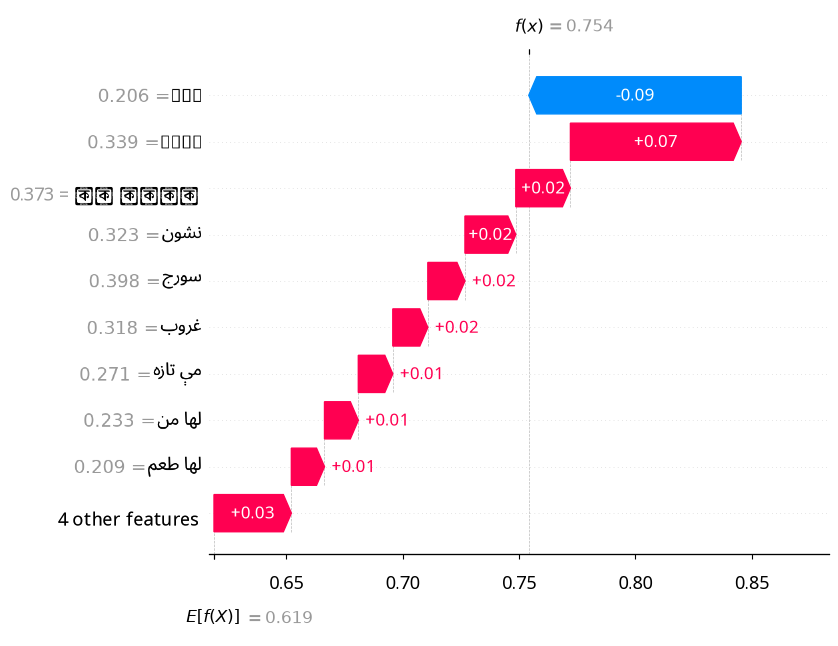

  ✅ Saved: waterfall_arabic.png


In [23]:
# Cell 6: Waterfall Plot
print("\n" + "="*80)
print("WATERFALL PLOT - ARABIC")
print("="*80)

if len(user_feature_names) > 0:
    plt.figure(figsize=(12, 8))
    waterfall(
        shap_values=shap_exp_user,
        max_display=min(10, len(shap_exp_user.values)),
        show=True
    )
    plt.show()
    save_plot("waterfall_arabic.png")
else:
    print("⚠️ Skipping waterfall plot - no features found")